## Preprocessing


This code was created on Aug 7th, expands on code "00".

## Setup notebook, and get paths 

In [1]:
from notebook_setup import setup
env = setup()

DATA_PATH = env["DATA_PATH"]
OUTPUT_PATH = env["OUTPUT_PATH"] / "01_notebook_experiments"

PREPROCESSED_PATH = env["PREPROCESSED_PATH"] / "01_first_analysises"
INPUT_DATA_PATH = env["PREPROCESSED_PATH"] / "00_just_converted_for_matlab_and_python"

# create preprocessed path if it does not exist
if not PREPROCESSED_PATH.exists():
    PREPROCESSED_PATH.mkdir(parents=True)

Added src path.
Enabled autoreload.
Current path is: /Users/adrian/Documents/01_projects/14_4D_lab/notebooks


In [2]:
from __future__ import annotations

import numpy as np
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

import bct

## Distance Matrix
Assumption: 
- There is no distance matrix yet. 
- weighted_adj_matrix: raw structural connectivity (i.e. number of streamlines)
- fc_mat: Functional connectivity 
- fiber_length_mat: streamline lengths 
-> Thus, the distance matrix is calculated from the coordinate file

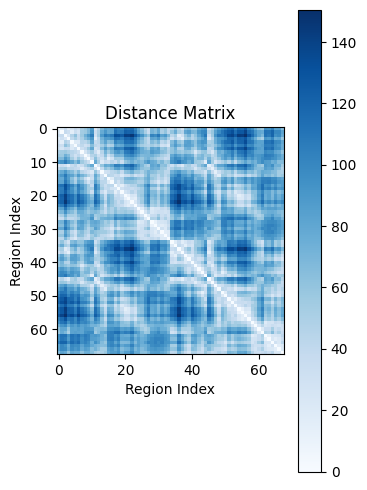

In [3]:
# Ensure dist_mat is symmetric with zeros on the diagonal
from preprocessing.preprocess_distance_matrix import get_distance_matrix

dist_mat = get_distance_matrix(raw_data_path=INPUT_DATA_PATH / "data_10_consensus/04_coordinates_68.csv", 
                               preprocessed_folder_path=PREPROCESSED_PATH,
                               plot=True)


## Individual connectomes

In [4]:
from preprocessing.preprocess_70_connectomes import get_individual_connectomes

all_connectomes, nsub, n = get_individual_connectomes(raw_data_path = INPUT_DATA_PATH / "data_700mb_individual_connectomes/SC_68.mat",
                                                       output_path = PREPROCESSED_PATH
                                                       )

Data shape: (70, 68, 68)
Statistics of all connectomes:
 Min: 0.0 
 Max: 0.12189800837138423 
 Mean: 0.0009902234262211787 
 Std: 0.004209923846361063
70 subjects | 68 × 68 matrices


## Threshold (i.e. binarize) networks

In [5]:
from netneurotools.networks import threshold_network

goal_density = 10 # in percent 
connectomes_binarized = np.array([threshold_network(all_connectomes[i], retain=10) for i in range(len(all_connectomes))])
connectome_densities = np.array([bct.density_und(connectomes_binarized[i])[0] for i in range(len(connectomes_binarized))])
print(f"Average density over all {len(connectomes_binarized)} subjects: {np.mean(connectome_densities)*100:.3f} percent.")

Average density over all 70 subjects: 9.965 percent.


## Get graph measures from empirical networks

In [6]:
# assume analyze_connectomes has been defined earlier
from structural_analysis.graph_measures import analyze_connectomes

df_graph_measures_bin = pd.DataFrame(analyze_connectomes(connectomes=connectomes_binarized, 
                                  distance_matrix=dist_mat, 
                                  comm_mode='estrada_scaled',
                                  rich_nodes_global=None,
                                  rich_top_percent=0.20
                                  ))


df_graph_measures_all = pd.DataFrame(analyze_connectomes(connectomes=all_connectomes, 
                                  distance_matrix=dist_mat, 
                                  comm_mode='estrada_scaled',
                                  rich_nodes_global=None,
                                  rich_top_percent=0.20
                                  ))
# save the dataframes
df_graph_measures_bin.to_csv(PREPROCESSED_PATH / "df_graph_measures_bin.csv")
df_graph_measures_all.to_csv(PREPROCESSED_PATH / "df_graph_measures_all.csv")

In [7]:
df_graph_measures_bin

,network_index,avg_communicability,global_efficiency,modularity,avg_clustering,avg_degree,transitivity,avg_edge_distance,char_path_length,richclub_n_edges,richclub_avg_length
0,0,0.017951,0.423039,0.469027,0.382721,6.676471,0.364172,40.159073,2.838894,31,50.958437
1,1,0.018366,0.431402,0.413971,0.374075,6.676471,0.326206,39.583551,2.748464,27,46.407775
2,2,0.018713,0.426500,0.490860,0.415409,6.676471,0.355263,39.210968,2.792362,29,46.939515
3,3,0.018307,0.437555,0.430835,0.419014,6.676471,0.320475,42.085731,2.676032,35,48.249990
4,4,0.017771,0.426252,0.443003,0.373213,6.676471,0.335808,39.074934,2.828797,33,44.750272
...,...,...,...,...,...,...,...,...,...,...,...
65,65,0.018894,0.428563,0.484805,0.398747,6.676471,0.344172,37.777603,2.761633,32,42.267483
66,66,0.019227,0.422286,0.501009,0.432620,6.676471,0.343066,38.617490,2.847234,27,44.802664
67,67,0.018081,0.421254,0.470832,0.401282,6.676471,0.370948,37.341551,2.846795,31,42.728958
68,68,0.018291,0.433465,0.443372,0.389193,6.676471,0.323407,39.486986,2.720808,30,46.708935


## Get identifiers (i.e. roi_name, hemisphere, etc)

In [8]:
df_identifiers = pd.read_csv(INPUT_DATA_PATH / "data_10_consensus/05_roi_names_rsn_name_hemisphere_68.csv", 
                             header=None, 
                             names=["roi_name", "roi_name_short", "rsn_name", "hemisphere"])

# get hemi_ids 
hemi_id = [0 if x == "rh" else 1 for x in df_identifiers["hemisphere"]]
df_identifiers["hemi_id"] = hemi_id
hemi_id = np.array(hemi_id)

# strip \r, \n, spaces from rsn_name 
df_identifiers = df_identifiers.applymap(lambda x: x.strip() if isinstance(x, str) else x)  # strip \r, \n, spaces

# save identifiers
df_identifiers.to_csv(PREPROCESSED_PATH / "df_identifiers.csv")
df_identifiers 

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_38332/1308841479.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_identifiers = df_identifiers.applymap(lambda x: x.strip() if isinstance(x, str) else x)  # strip \r, \n, spaces


,roi_name,roi_name_short,rsn_name,hemisphere,hemi_id
0,lateralorbitofrontal,LOF,ventralattention,rh,0
1,parsorbitalis,PORB,cinguloopercular,rh,0
2,frontalpole,FP,frontoparietal,rh,0
3,medialorbitofrontal,MOF,frontoparietal,rh,0
4,parstriangularis,PTRI,frontoparietal,rh,0
...,...,...,...,...,...
63,middletemporal,MT,other,lh,1
64,bankssts,BSTS,auditory,lh,1
65,superiortemporal,ST,auditory,lh,1
66,transversetemporal,TT,auditory,lh,1


## Get structural consensus connectomes

In [9]:
# Build consensus connectome from binarized connectomes
from netneurotools.networks import struct_consensus

# get consensus connectome of binarized network
consensus_conn_bin = struct_consensus(connectomes_binarized.T, distance=dist_mat, hemiid=hemi_id.reshape(-1, 1))
consensus_density_bin = bct.density_und(consensus_conn_bin)[0] 
print(f"Consensus connectome density: {consensus_density_bin*100:.2f} %.")

# get consensure connectome of weighted network 
consensus_conn_all = struct_consensus(all_connectomes.T, distance=dist_mat, hemiid=hemi_id.reshape(-1, 1))
consensus_density_all = bct.density_und(consensus_conn_all)[0]  #
print(f"Consensus connectome density: {consensus_density_all*100:.2f} %.")

# save consensus connectomes
np.save(PREPROCESSED_PATH / "consensus_connectome_bin.npy", consensus_conn_bin)
np.save(PREPROCESSED_PATH / "consensus_connectome_all.npy", consensus_conn_all)

Consensus connectome density: 9.83 %.
Consensus connectome density: 26.69 %.


Text(0.5, 0.98, 'Consensus Connectomes Differ If Binarization Is Performed Before The Calculation Of Consensus \n (and density also differs)')

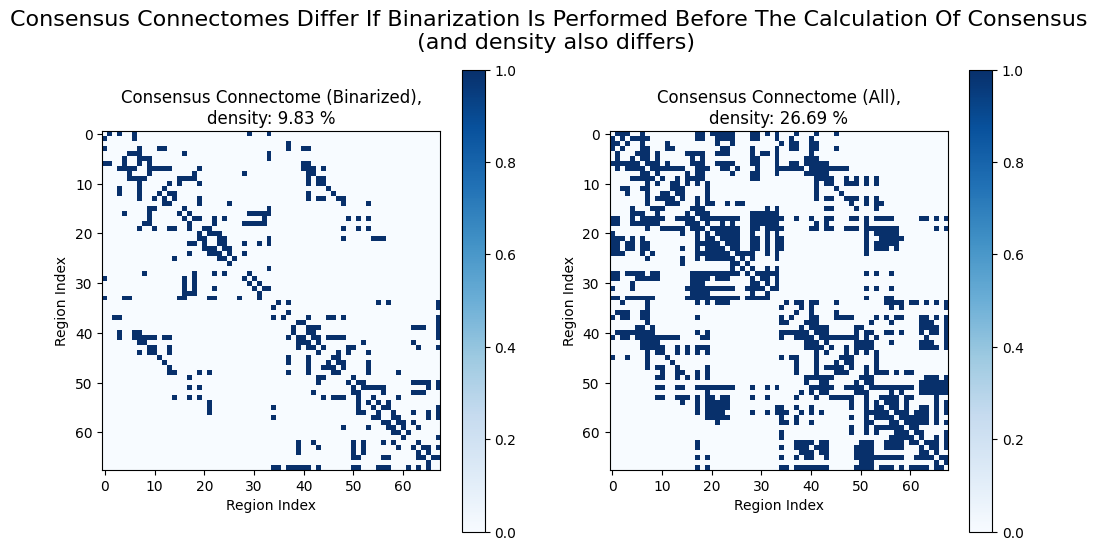

In [10]:
plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)

plt.imshow(consensus_conn_bin, cmap='Blues')
plt.colorbar()
plt.xlabel("Region Index")
plt.ylabel("Region Index")
plt.title(f"Consensus Connectome (Binarized),\ndensity: {consensus_density_bin*100:.2f} %")


plt.subplot(1,2,2)
plt.imshow(consensus_conn_all, cmap='Blues')
plt.colorbar()
plt.xlabel("Region Index")
plt.ylabel("Region Index")
plt.title(f"Consensus Connectome (All),\ndensity: {consensus_density_all*100:.2f} %")

plt.suptitle("Consensus Connectomes Differ If Binarization Is Performed Before The Calculation Of Consensus \n (and density also differs)", fontsize=16)
